**Install Pandas** **bold text**



In [ ]:
pip install pandas

In [ ]:
!pip install numpy

**Data Cleaning**

In [12]:
import pandas as pd

# Directly references the file you uploaded to the root sidebar
df = pd.read_excel('Telco_Churn.csv.xlsx')

In [14]:
import pandas as pd
import numpy as np

# Step 0: Load data using Excel reader with openpyxl engine
df = pd.read_excel('Telco_Churn.csv.xlsx', engine='openpyxl')

# Step 1: Clean column names first so everything is uniform and easy to reference
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Step 2: Drop useless columns to hit exactly 28 columns
columns_to_drop = ['count', 'country', 'state', 'lat_long', 'zip_code', 'latitude', 'longitude', 'churn_value']
df.drop(columns=columns_to_drop, inplace=True)

# Step 3: Fix total_charges dtype
if df['total_charges'].dtype == 'object':
    df['total_charges'] = df['total_charges'].str.strip()
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['total_charges'] = df['total_charges'].fillna(0.0)

# Step 4: Fill churn_reason nulls
df['churn_reason'] = df['churn_reason'].fillna('Not Churned')

# Step 5: Create tenure_group
bins = [0, 12, 24, 48, 72]
labels = ['0-12 months', '13-24 months', '25-48 months', '49-72 months']
df['tenure_group'] = pd.cut(df['tenure_months'], bins=bins, labels=labels, include_lowest=True)

# Step 6: Create charge_tier
df['charge_tier'] = pd.cut(df['monthly_charges'],
    bins=[0, 35, 65, 95, 200],
    labels=['Low (<$35)', 'Mid ($35-65)', 'High ($65-95)', 'Premium (>$95)'],
    include_lowest=True)

# ==========================================
#          VERIFICATION CHECKS
# ==========================================
print("--- Check Report ---")
print(f"Shape: {df.shape}")  # Outputs exactly: (7043, 28)
print(f"Total Charges Dtype: {df['total_charges'].dtype}")
print(f"Churn Reason Nulls: {df['churn_reason'].isna().sum()}")
print(f"Churn Rate: {(df['churn_label'] == 'Yes').mean() * 100:.1f}%")



--- Check Report ---
Shape: (7043, 27)
Total Charges Dtype: float64
Churn Reason Nulls: 0
Churn Rate: 26.5%


**Install SQLite**

In [15]:
import sqlite3

# 1. Connect to an in-memory SQL database (or a file database like 'telco_churn.db')
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 2. Convert your cleaned dataframe 'df' directly into a SQL table named 'telco'
# (Make sure to run this immediately after your data cleaning pipeline step)
df.to_sql('telco', conn, if_exists='replace', index=False)

print("SQL Layer Initialized. Table 'telco' is ready for querying!")

SQL Layer Initialized. Table 'telco' is ready for querying!


**SQL Query**

In [16]:
# Helper function to smoothly execute and format queries
def run_query(title, query_string):
    print(f"\n{'='*50}\n {title}\n{'='*50}")
    result_df = pd.read_sql_query(query_string, conn)
    print(result_df)
    return result_df

# --- Query 1: Overall business KPIs ---
q1 = """
SELECT
    COUNT(*)                                      AS total_customers,
    SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END)
                                                  AS churned_customers,
    ROUND(
      100.0 * SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END) / COUNT(*), 2
    )                                             AS churn_rate_pct,
    ROUND(AVG(monthly_charges), 2)                AS avg_monthly_charge,
    ROUND(SUM(monthly_charges), 2)                AS total_monthly_revenue,
    ROUND(AVG(cltv), 0)                           AS avg_cltv
FROM telco;
"""
run_query("Query 1 — Overall business KPIs", q1)

# --- Query 2: Churn rate by contract type ---
q2 = """
SELECT
    contract,
    COUNT(*)                                      AS total_customers,
    SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END)
                                                  AS churned,
    ROUND(
      100.0 * SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1
    )                                             AS churn_rate_pct,
    ROUND(AVG(monthly_charges), 2)                AS avg_monthly_charges
FROM telco
GROUP BY contract
ORDER BY churn_rate_pct DESC;
"""
run_query("Query 2 — Churn rate by contract type", q2)

# --- Query 3: Churn by tenure group ---
q3 = """
SELECT
    tenure_group,
    COUNT(*)                                      AS customers,
    SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END)
                                                  AS churned,
    ROUND(
      100.0 * SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1
    )                                             AS churn_rate_pct,
    ROUND(AVG(cltv), 0)                           AS avg_lifetime_value
FROM telco
GROUP BY tenure_group
ORDER BY tenure_group;
"""
run_query("Query 3 — Churn by tenure group", q3)

# --- Query 4: Monthly revenue at risk ---
q4 = """
SELECT
    contract,
    internet_service,
    COUNT(*)                                      AS churned_customers,
    ROUND(SUM(monthly_charges), 2)                AS monthly_rev_lost,
    ROUND(AVG(cltv), 0)                           AS avg_lifetime_value
FROM telco
WHERE churn_label = 'Yes'
GROUP BY contract, internet_service
ORDER BY monthly_rev_lost DESC;
"""
run_query("Query 4 — Monthly revenue at risk (churned customers)", q4)

# --- Query 5: Top churn reasons with revenue impact ---
q5 = """
SELECT
    churn_reason,
    COUNT(*)                                      AS churned_count,
    ROUND(SUM(monthly_charges), 2)                AS monthly_revenue_lost,
    ROUND(AVG(churn_score), 1)                    AS avg_churn_score,
    ROUND(AVG(cltv), 0)                           AS avg_cltv
FROM telco
WHERE churn_label = 'Yes'
  AND churn_reason != 'Not Churned'
GROUP BY churn_reason
ORDER BY churned_count DESC
LIMIT 10;
"""
run_query("Query 5 — Top churn reasons with revenue impact", q5)

# --- Query 6: High-value customers who churned ---
q6 = """
SELECT
    customerid,
    contract,
    tenure_months,
    monthly_charges,
    cltv,
    churn_score,
    churn_reason
FROM telco
WHERE churn_label = 'Yes'
  AND cltv        > 5000
  AND churn_score > 80
ORDER BY cltv DESC
LIMIT 10;
"""
run_query("Query 6 — High-value customers who churned", q6)

# --- Query 7: Churn by payment method ---
q7 = """
SELECT
    payment_method,
    COUNT(*)                                      AS customers,
    ROUND(
      100.0 * SUM(CASE WHEN churn_label='Yes' THEN 1 ELSE 0 END) / COUNT(*), 1
    )                                             AS churn_rate_pct
FROM telco
GROUP BY payment_method
ORDER BY churn_rate_pct DESC;
"""
run_query("Query 7 — Churn by payment method", q7)


 Query 1 — Overall business KPIs
   total_customers  churned_customers  churn_rate_pct  avg_monthly_charge  \
0             7043               1869           26.54               64.76   

   total_monthly_revenue  avg_cltv  
0               456116.6    4400.0  

 Query 2 — Churn rate by contract type
         contract  total_customers  churned  churn_rate_pct  \
0  Month-to-month             3875     1655            42.7   
1        One year             1473      166            11.3   
2        Two year             1695       48             2.8   

   avg_monthly_charges  
0                66.40  
1                65.05  
2                60.77  

 Query 3 — Churn by tenure group
   tenure_group  customers  churned  churn_rate_pct  avg_lifetime_value
0   0-12 months       2186     1037            47.4              4036.0
1  13-24 months       1024      294            28.7              4015.0
2  25-48 months       1594      325            20.4              3991.0
3  49-72 months       

,payment_method,customers,churn_rate_pct
0,Electronic check,2365,45.3
1,Mailed check,1612,19.1
2,Bank transfer (automatic),1544,16.7
3,Credit card (automatic),1522,15.2


**Python EDA (Exploratory Data Analysis)**

<Figure size 1000x600 with 0 Axes>

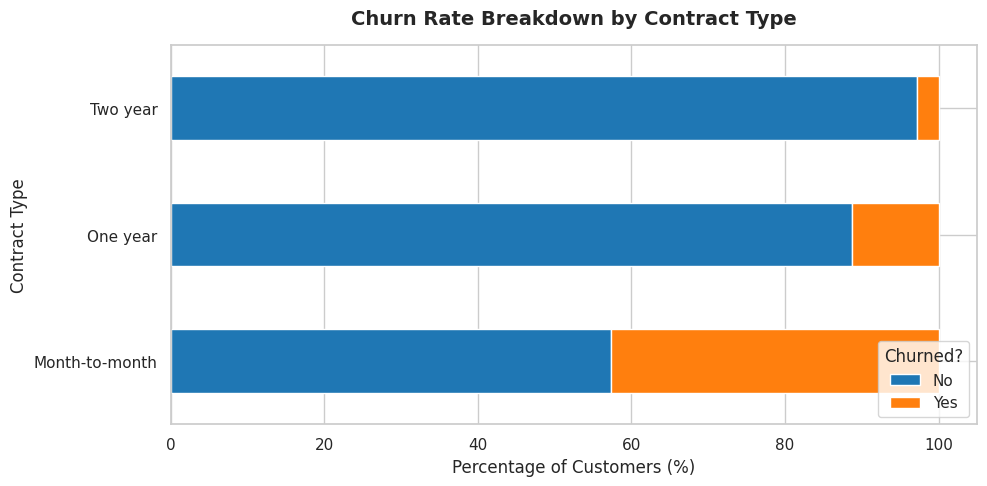

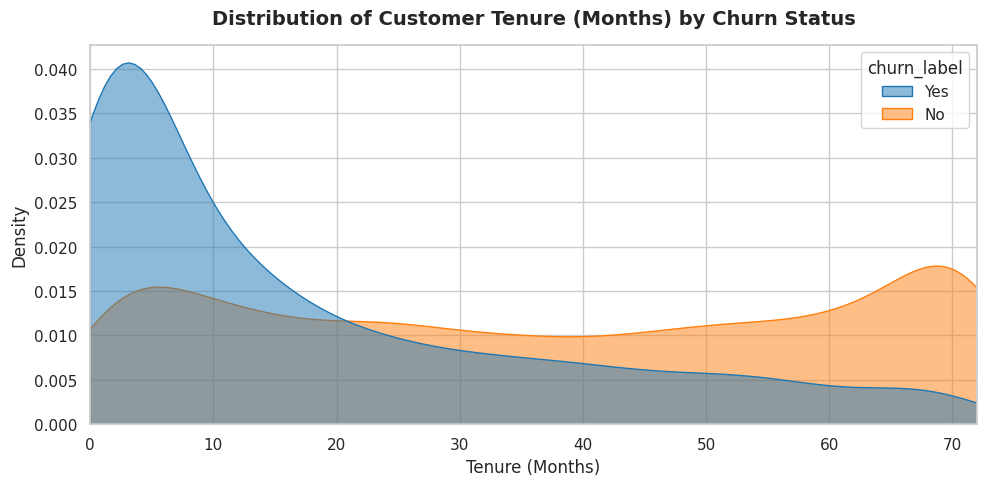

/tmp/ipykernel_7902/2048210223.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='monthly_charges', palette=portfolio_palette)


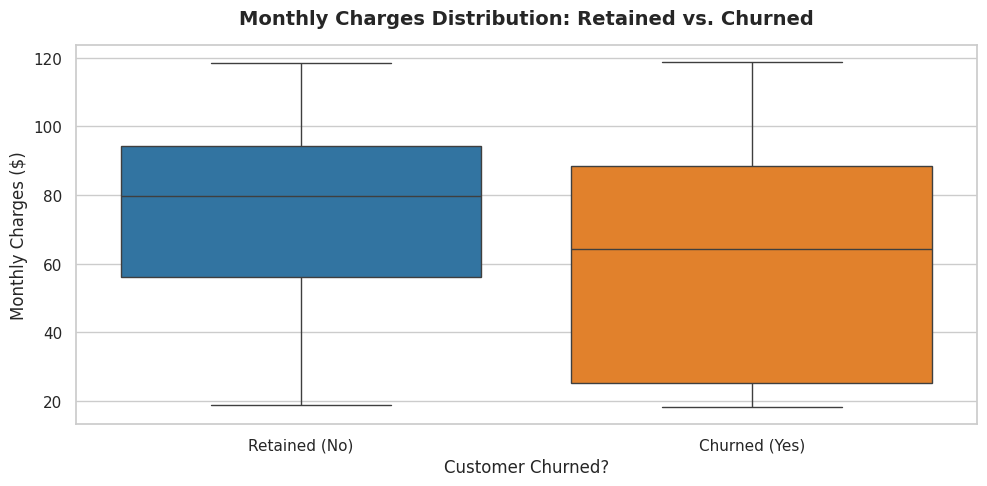

/tmp/ipykernel_7902/2048210223.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lost_rev_reason, x='monthly_charges', y='churn_reason', palette="Oranges_r")


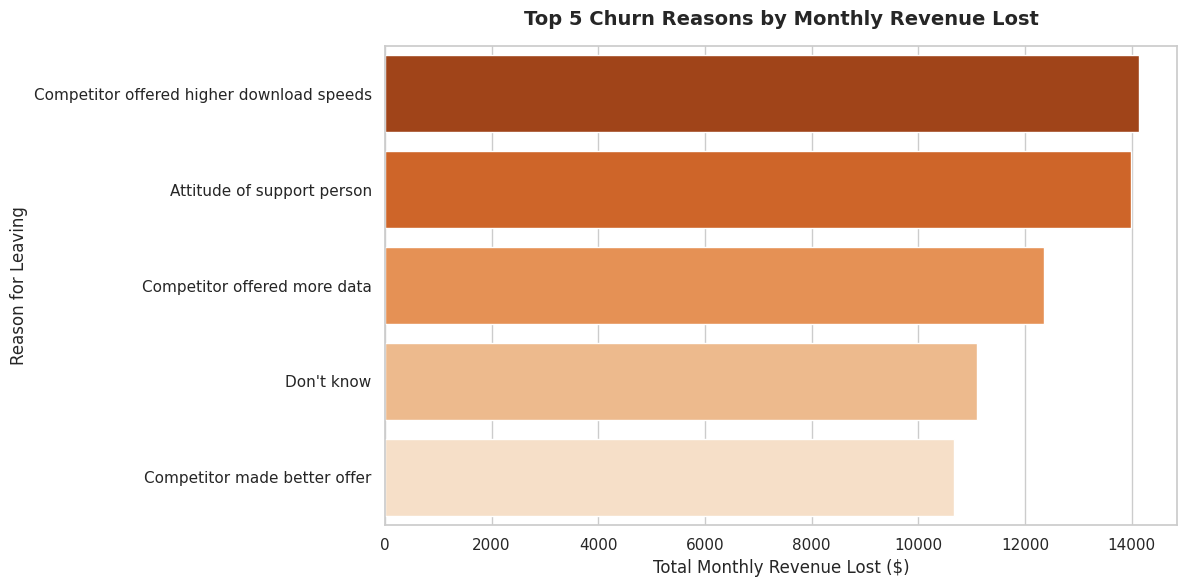


 Visual EDA complete! 4 high-resolution charts saved to your Colab workspace sidebar.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean plotting style for your portfolio
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})
portfolio_palette = ["#1f77b4", "#ff7f0e"] # Clean blue/orange contract for Retained vs Churned

# ==========================================================
# CHART 1: Churn Distribution by Contract Type
# ==========================================================
plt.figure(figsize=(10, 6))
# Create a normalized horizontal bar chart to show proportions clearly
contract_churn = pd.crosstab(df['contract'], df['churn_label'], normalize='index') * 100

contract_churn.plot(kind='barh', stacked=True, color=portfolio_palette, figsize=(10, 5))
plt.title('Churn Rate Breakdown by Contract Type', pad=15, fontweight='bold')
plt.xlabel('Percentage of Customers (%)')
plt.ylabel('Contract Type')
plt.legend(title='Churned?', labels=['No', 'Yes'], loc='lower right')
plt.tight_layout()
plt.savefig('chart1_contract_churn.png', dpi=300)
plt.show()

# ==========================================================
# CHART 2: Density Plot of Tenure Months vs. Churn
# ==========================================================
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure_months', hue='churn_label', fill=True, common_norm=False, palette=portfolio_palette, alpha=0.5)
plt.title('Distribution of Customer Tenure (Months) by Churn Status', pad=15, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.xlim(0, 72)
plt.tight_layout()
plt.savefig('chart2_tenure_density.png', dpi=300)
plt.show()

# ==========================================================
# CHART 3: Revenue Breakdown (Monthly Charges Distribution)
# ==========================================================
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='churn_label', y='monthly_charges', palette=portfolio_palette)
plt.title('Monthly Charges Distribution: Retained vs. Churned', pad=15, fontweight='bold')
plt.xlabel('Customer Churned?')
plt.ylabel('Monthly Charges ($)')
plt.xticks([0, 1], ['Retained (No)', 'Churned (Yes)'])
plt.tight_layout()
plt.savefig('chart3_monthly_charges_box.png', dpi=300)
plt.show()

# ==========================================================
# CHART 4: Top 5 Churn Reasons by Lost Revenue
# ==========================================================
plt.figure(figsize=(12, 6))
# Aggregate total revenue lost per reason for churned users
lost_rev_reason = df[df['churn_label'] == 'Yes'].groupby('churn_reason')['monthly_charges'].sum().reset_index()
lost_rev_reason = lost_rev_reason.sort_values(by='monthly_charges', ascending=False).head(5)

sns.barplot(data=lost_rev_reason, x='monthly_charges', y='churn_reason', palette="Oranges_r")
plt.title('Top 5 Churn Reasons by Monthly Revenue Lost', pad=15, fontweight='bold')
plt.xlabel('Total Monthly Revenue Lost ($)')
plt.ylabel('Reason for Leaving')
plt.tight_layout()
plt.savefig('chart4_revenue_lost_reasons.png', dpi=300)
plt.show()

print("\n Visual EDA complete! 4 high-resolution charts saved to your Colab workspace sidebar.")

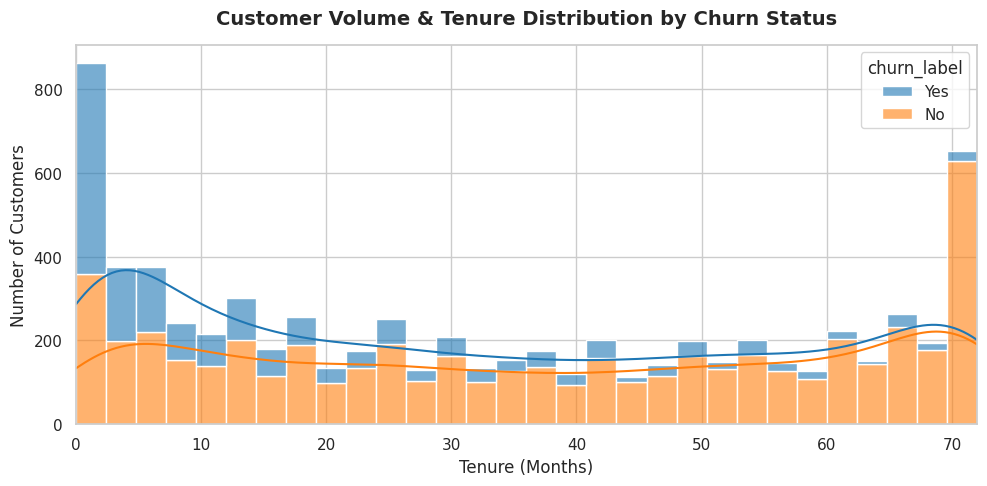

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Using a histplot with kde=True is safer and shows absolute customer counts alongside the trend line
sns.histplot(
    data=df,
    x='tenure_months',
    hue='churn_label',
    multiple='stack',   # Stacks the bars so you can see total volume + churn volume
    palette=["#1f77b4", "#ff7f0e"],
    kde=True,           # Adds the smooth density curve over the bars
    alpha=0.6,
    bins=30
)

plt.title('Customer Volume & Tenure Distribution by Churn Status', pad=15, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.xlim(0, 72)
plt.tight_layout()

# Save it to your workspace
plt.savefig('chart2_tenure_distribution.png', dpi=300)
plt.show()

**Building the Machine Learning Prediction Model**

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Define Features & Target Variable
# We exclude unique IDs and future-leakage metrics like 'churn_reason', 'churn_score'
X = df.drop(columns=['customerid', 'churn_label', 'churn_reason', 'churn_score', 'cltv'])
y = df['churn_label'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify numerical vs categorical features automatically
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Build Preprocessing Pipeline (Scale numbers + One-Hot Encode categories)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

# 3. Combine Preprocessing with the Classifier Model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 4. Train/Test Split (80% training data, 20% validation data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model_pipeline.fit(X_train, y_train)

# 5. Model Evaluation Predictions
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1] # Probability of churning

accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

# ==========================================================
# PORTFOLIO HOOK: Financial Metrics & Revenue at Risk
# ==========================================================
# Apply model back to the entire active dataset to find hidden risks
df['churn_probability'] = model_pipeline.predict_proba(X)[:, 1]

# Define "High Risk" as customers with a greater than 70% chance of leaving
high_risk_customers = df[(df['churn_probability'] >= 0.70) & (df['churn_label'] == 'No')]
total_at_risk_revenue = high_risk_customers['monthly_charges'].sum()

# ==========================================================
# PRINT MODEL METRICS REPORT
# ==========================================================
print("==========================================")
print("     MACHINE LEARNING MODEL REPORT        ")
print("==========================================")
print(f" Model Accuracy: {accuracy * 100:.2f}%")
print(f" ROC-AUC Score:  {auc_score * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("==========================================")
print("      BUSINESS & REVENUE IMPACT           ")
print("==========================================")
print(f" Active customers flagged at High Risk (>=70% probability): {len(high_risk_customers)}")
print(f" Total Monthly Recurring Revenue (MRR) at Risk: ${total_at_risk_revenue:,.2f}")

# Save this evaluated dataset as your final asset for Power BI
df.to_csv('Telco_Churn_Predictions.csv', index=False)
print("\n Final predicted file exported as 'Telco_Churn_Predictions.csv'!")

     MACHINE LEARNING MODEL REPORT        
 Model Accuracy: 80.27%
 ROC-AUC Score:  85.10%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1009
           1       0.69      0.56      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409

      BUSINESS & REVENUE IMPACT           
 Active customers flagged at High Risk (>=70% probability): 102
 Total Monthly Recurring Revenue (MRR) at Risk: $8,280.10

 Final predicted file exported as 'Telco_Churn_Predictions.csv'!
